
Fetching runs...
Found 360 runs


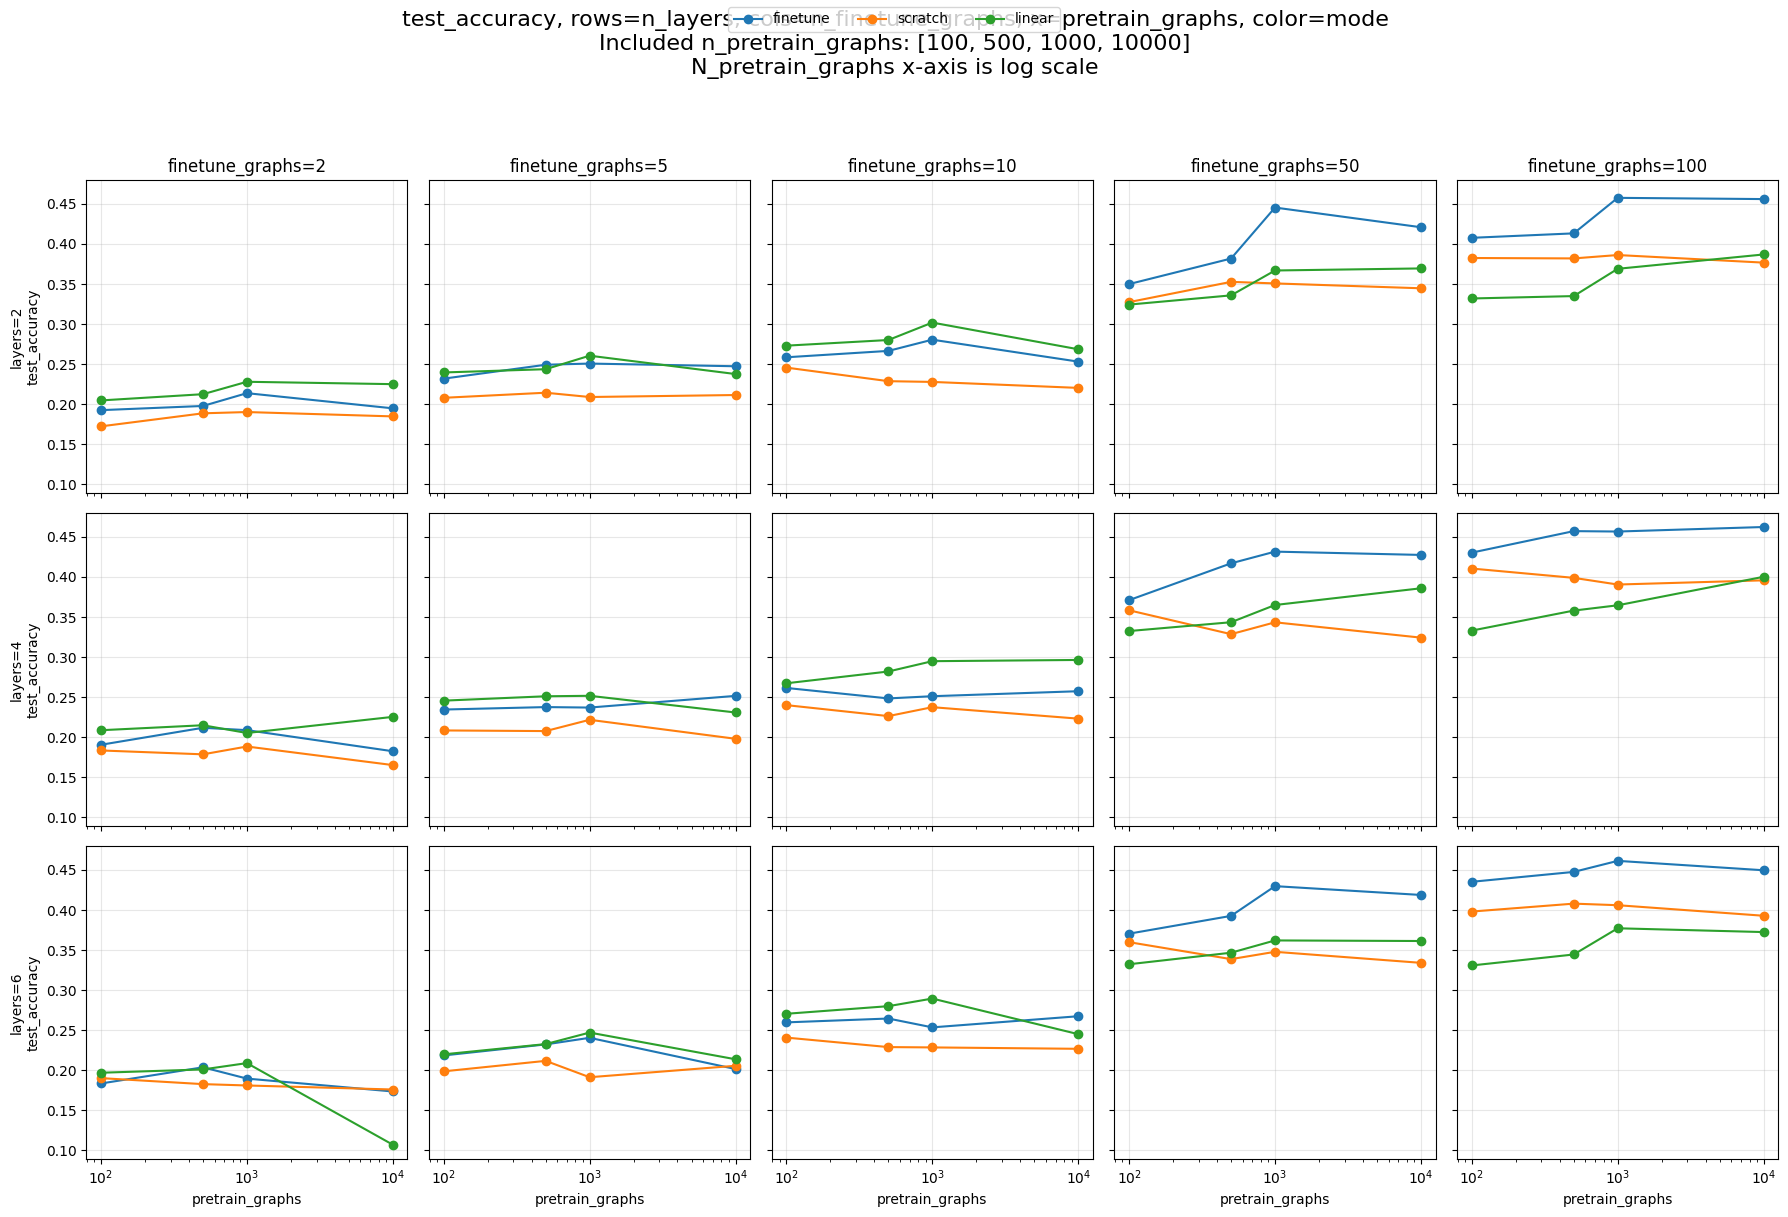

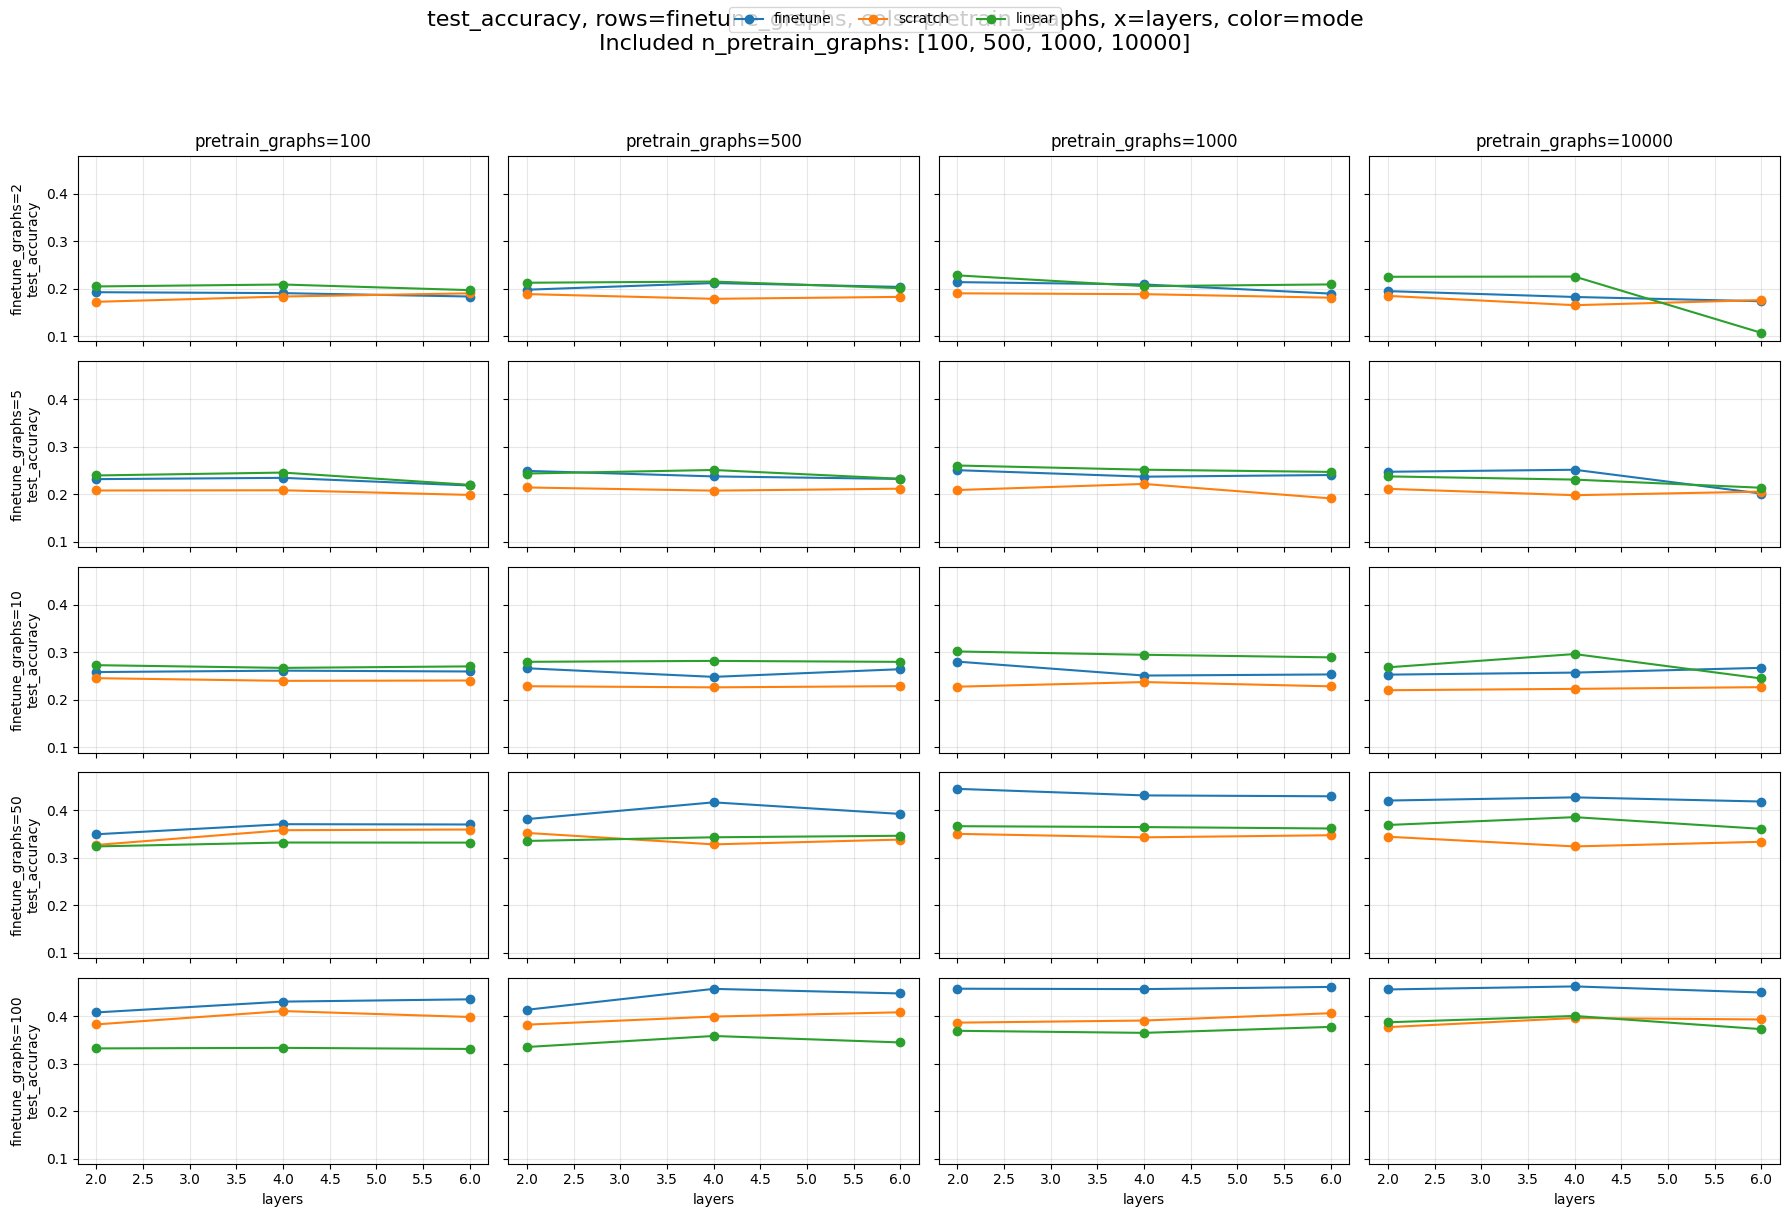

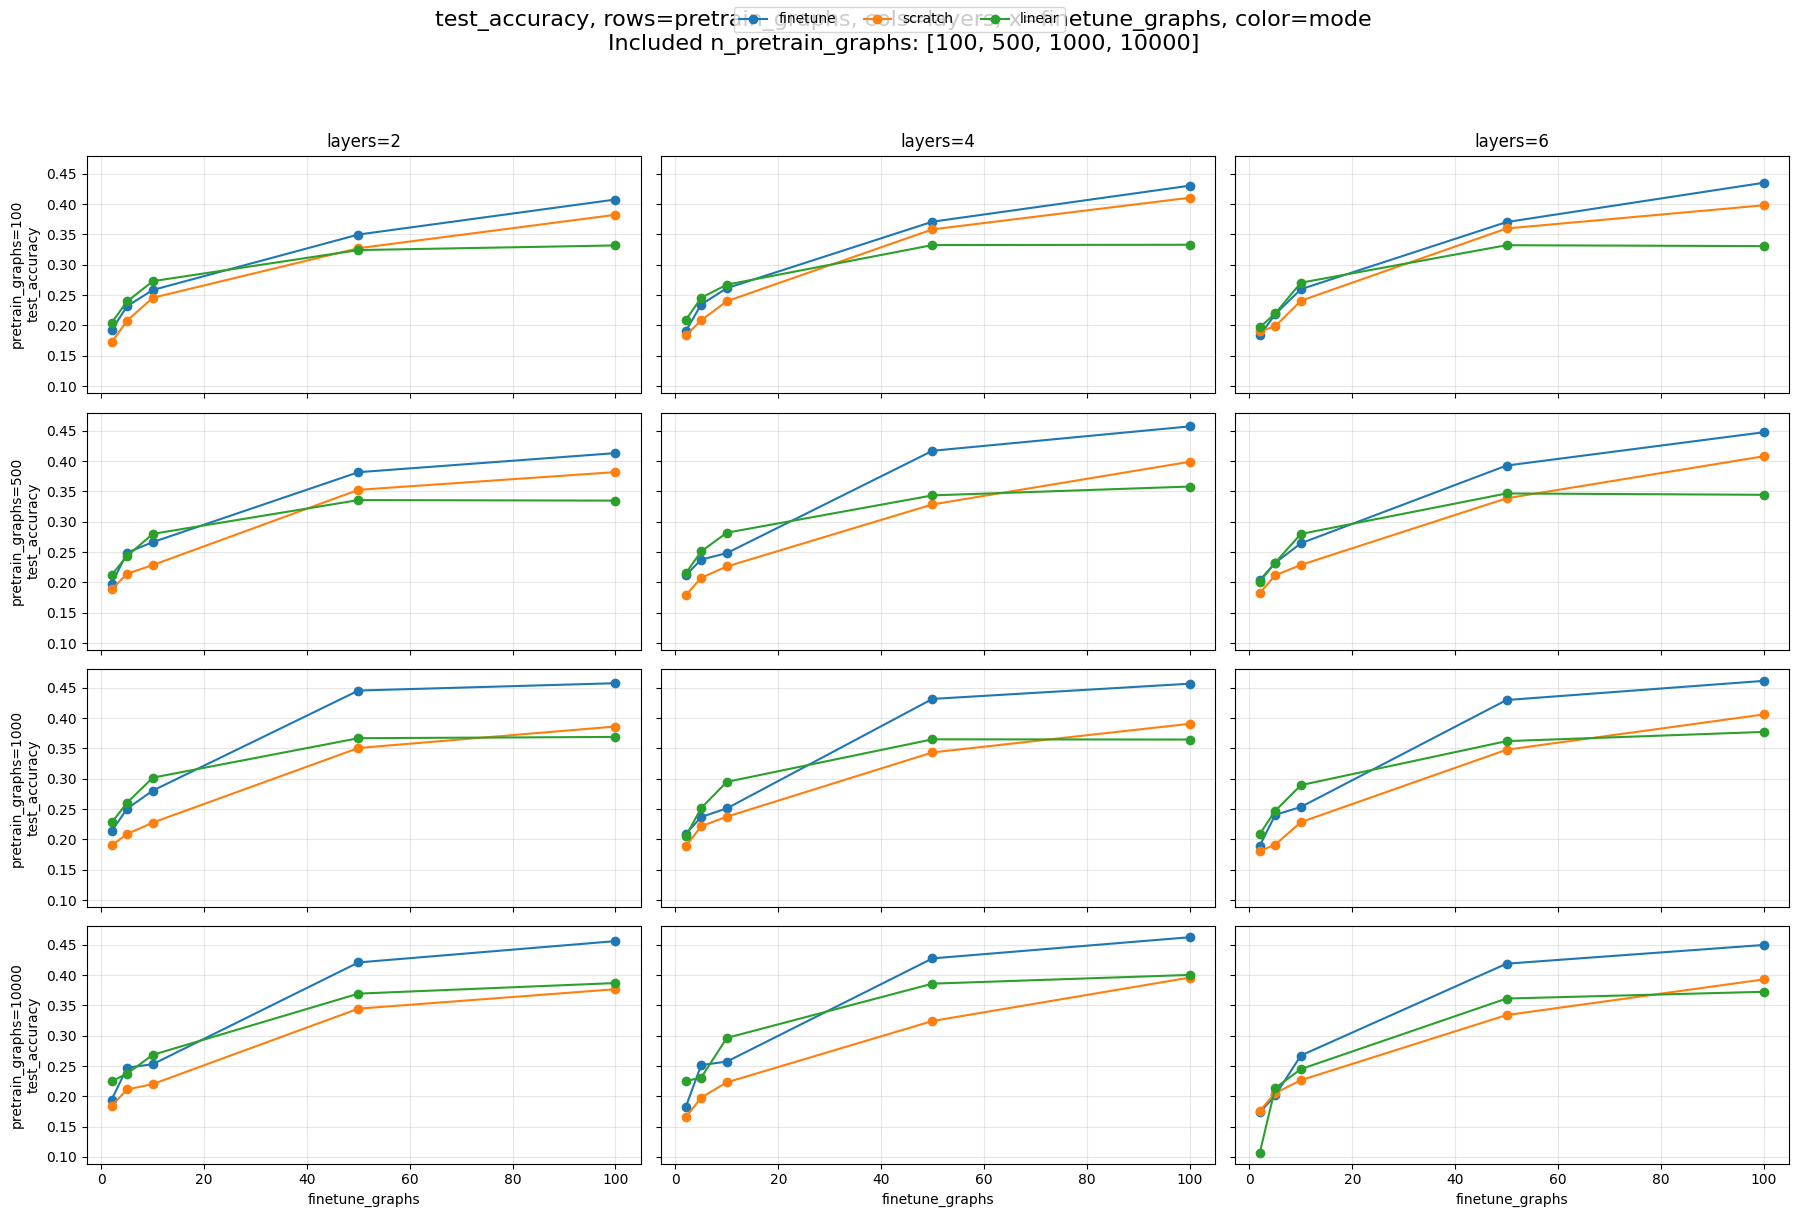

In [20]:
import argparse
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple, Any, Optional
import wandb

def extract_pretrained_model_name(run_dir):
    if run_dir is None:
        return "Unknown"
    run_dir_str = str(run_dir)
    if "run-" in run_dir_str:
        parts = run_dir_str.split("run-")[-1]
        wandb_id = parts.split("-")[-1]
        return wandb_id
    return "Unknown"

def load_runs_from_wandb_general(
    entity: str = "louis-van-langendonck-universitat-polit-cnica-de-catalunya",
    project: str = "graphmaev2_gps_scaling",
    model_name_to_n_layers_map: dict = None,
    model_name_to_n_graphs_map: dict = None,
    ):

    api = wandb.Api()
    project_path = f"{entity}/{project}" if entity else project

    print(f"\nFetching runs...")
    runs = api.runs(project_path)
    print(f"Found {len(runs)} runs")

    data = []
    config_example = None
    for run in runs:
        try:
            config = run.config
            if config_example is None:
                config_example = config
            summary = run.summary

            pretrained_run_dir = config.get("pretraining_run", None)
            pretrained_model = extract_pretrained_model_name(pretrained_run_dir)

            n_layers_used_for_pretraining = model_name_to_n_layers_map.get(pretrained_model, None)
            n_graphs_used_for_pretraining = model_name_to_n_graphs_map.get(pretrained_model, None)

            mode = config.get("mode", "unknown")
            test_accuracy = summary.get("test/accuracy", None)
            test_mae = summary.get("test/mae", None)
            n_train = config.get("n_train", None)
            n_evaluation_graphs = config.get("n_evaluation_graphs", None)
            task_type = config.get("task_type", "classification")
            task_level = config.get("task_level", "node")

            row = {
                    "run_id": run.id,
                    "run_name": run.name,
                    "pretrained_model": pretrained_model,
                    "mode": mode,
                    "test_accuracy": test_accuracy,
                    "test_mae": test_mae,
                    "n_train": n_train,
                    "n_evaluation_graphs": n_evaluation_graphs,
                    "task_type": task_type,
                    "task_level": task_level,
                    "pretrained_run_dir": pretrained_run_dir,
                    "n_layers_used_for_pretraining": n_layers_used_for_pretraining,
                    "n_graphs_used_for_pretraining": n_graphs_used_for_pretraining,
                }
            data.append(row)
        except Exception as e:
            print(f"Warning: Failed to process run {getattr(run,'id',str(run))}: {e}")
            continue

    df = pd.DataFrame(data)

    return df, config_example

# ==== Constants and mappings ====
INCLUDED_MODES = ['finetune', 'scratch', 'linear', 'gpf-linear', 'gpf-plus-linear', 'untrained_frozen']
INCLUDED_N_PRETRAIN_GRAPHS = None  # Will be set by user to a list of included n_pretrain_graphs; use None for all.
DEFAULT_OUTPUT_DIR = "results"
DEFAULT_FORMAT = "PNG"
DEFAULT_METRIC = "test_accuracy"
DEFAULT_FIGSIZE = (18, 12)
MODEL_NAME_TO_N_LAYERS_MAP = {
    'wsvy2lgl': 2, 'a38h4ciy': 4, '5aqppii6': 6,
    '359h1e0z': 2, 'x5pr4ngx': 4, 'a8yhf9dx': 6,
    'a2uxmaru': 2, 'jfpk3r9q': 4, '41xjgl70': 6,
    'ouv6ofkx': 2, 'iriba52l': 4, '2ee76lf5': 6
}
MODEL_NAME_TO_N_PRETRAINING_GRAPHS_MAP = {
    'wsvy2lgl': 100, 'a38h4ciy': 100, '5aqppii6': 100,
    '359h1e0z': 500, 'x5pr4ngx': 500, 'a8yhf9dx': 500,
    'a2uxmaru': 1000, 'jfpk3r9q': 1000, '41xjgl70': 1000,
    'ouv6ofkx': 10000, 'iriba52l': 10000, '2ee76lf5': 10000
}

df, config_example = load_runs_from_wandb_general(
    model_name_to_n_layers_map=MODEL_NAME_TO_N_LAYERS_MAP,
    model_name_to_n_graphs_map=MODEL_NAME_TO_N_PRETRAINING_GRAPHS_MAP,
)

# Add short named columns for clarity
df = df.copy()
df['mode'] = df['mode'].astype(str)
df['n_layers'] = df['n_layers_used_for_pretraining']
df['n_pretrain_graphs'] = df['n_graphs_used_for_pretraining']
df['n_finetune_graphs'] = df['n_train']


def plot_scaling_grid(
    df: pd.DataFrame,
    included_modes: List[str] = INCLUDED_MODES,
    included_n_pretrain_graphs: Optional[List[int]] = INCLUDED_N_PRETRAIN_GRAPHS,
    metric: str = DEFAULT_METRIC,
    figsize=(18,12),
    output_prefix: Optional[str] = None,
    log_pretrain_xaxis: bool = False,  # <--- NEW: whether to plot n_pretrain_graphs x-axis in log scale
):
    import seaborn as sns
    from itertools import product

    # Filtering by included_n_pretrain_graphs if specified
    if included_n_pretrain_graphs is not None:
        df = df[df['n_pretrain_graphs'].isin(included_n_pretrain_graphs)]

    # Define color map per mode (reuseable)
    palette = sns.color_palette("tab10", n_colors=len(included_modes))
    mode_colors = {mode: palette[i % len(palette)] for i, mode in enumerate(included_modes)}

    # 1. ROWS: n_layers, SUBCOLS: n_finetune_graphs, X: pretrain_graphs
    row_vals = sorted(df['n_layers'].dropna().unique())
    col_vals = sorted(df['n_finetune_graphs'].dropna().unique())
    x_vals = sorted(df['n_pretrain_graphs'].dropna().unique())

    fig1, axes1 = plt.subplots(len(row_vals), len(col_vals), figsize=figsize, squeeze=False, sharex=True, sharey=True)
    for irow, n_layers in enumerate(row_vals):
        for icol, n_finetune_graphs in enumerate(col_vals):
            ax = axes1[irow][icol]
            subdf = df[(df['n_layers'] == n_layers) & (df['n_finetune_graphs'] == n_finetune_graphs)]
            for mode in included_modes:
                mode_df = subdf[subdf['mode'] == mode]
                points = mode_df.groupby('n_pretrain_graphs')[metric].mean().reset_index()
                if not points.empty:
                    ax.plot(points['n_pretrain_graphs'], points[metric], marker='o', label=mode, color=mode_colors[mode])
            if irow == 0:
                ax.set_title(f"finetune_graphs={n_finetune_graphs}")
            if icol == 0:
                ax.set_ylabel(f"layers={n_layers}\n{metric}")
            if irow == len(row_vals)-1:
                ax.set_xlabel("pretrain_graphs")
            ax.grid(True, alpha=0.3)
            # Set log x-axis if requested
            if log_pretrain_xaxis:
                ax.set_xscale('log')
    handles, labels = axes1[0][0].get_legend_handles_labels()
    fig1.legend(handles, labels, loc='upper center', ncol=len(included_modes))
    fig1.suptitle(
        f"{metric}, rows=n_layers, cols=n_finetune_graphs, x=pretrain_graphs, color=mode"
        + (f"\nIncluded n_pretrain_graphs: {included_n_pretrain_graphs}" if included_n_pretrain_graphs is not None else "")
        + ("\nN_pretrain_graphs x-axis is log scale" if log_pretrain_xaxis else ""),
        y=1.01, fontsize=16,
    )
    fig1.tight_layout(rect=[0,0,1,0.97])
    if output_prefix:
        fig1.savefig(f"{output_prefix}_rows-layers_cols-finetunegraphs_x-pretraingraphs.{DEFAULT_FORMAT.lower()}", dpi=200)

    # 2. ROW: n_finetune_graphs, COL: pretrain_graphs, X: n_layers
    row_vals = sorted(df['n_finetune_graphs'].dropna().unique())
    col_vals = sorted(df['n_pretrain_graphs'].dropna().unique())
    x_vals = sorted(df['n_layers'].dropna().unique())

    fig2, axes2 = plt.subplots(len(row_vals), len(col_vals), figsize=figsize, squeeze=False, sharex=True, sharey=True)
    for irow, n_finetune_graphs in enumerate(row_vals):
        for icol, n_pretrain_graphs in enumerate(col_vals):
            ax = axes2[irow][icol]
            subdf = df[(df['n_finetune_graphs'] == n_finetune_graphs) & (df['n_pretrain_graphs'] == n_pretrain_graphs)]
            for mode in included_modes:
                mode_df = subdf[subdf['mode'] == mode]
                points = mode_df.groupby('n_layers')[metric].mean().reset_index()
                if not points.empty:
                    ax.plot(points['n_layers'], points[metric], marker='o', label=mode, color=mode_colors[mode])
            if irow == 0:
                ax.set_title(f"pretrain_graphs={n_pretrain_graphs}")
            if icol == 0:
                ax.set_ylabel(f"finetune_graphs={n_finetune_graphs}\n{metric}")
            if irow == len(row_vals) - 1:
                ax.set_xlabel("layers")
            ax.grid(True, alpha=0.3)
    handles, labels = axes2[0][0].get_legend_handles_labels()
    fig2.legend(handles, labels, loc='upper center', ncol=len(included_modes))
    fig2.suptitle(
        f"{metric}, rows=finetune_graphs, cols=pretrain_graphs, x=layers, color=mode"
        + (f"\nIncluded n_pretrain_graphs: {included_n_pretrain_graphs}" if included_n_pretrain_graphs is not None else ""),
        y=1.01, fontsize=16,
    )
    fig2.tight_layout(rect=[0,0,1,0.97])
    if output_prefix:
        fig2.savefig(f"{output_prefix}_rows-finetunegraphs_cols-pretraingraphs_x-layers.{DEFAULT_FORMAT.lower()}", dpi=200)

    # 3. ROW: pretrain_graphs, COL: layers, X: finetune_graphs
    row_vals = sorted(df['n_pretrain_graphs'].dropna().unique())
    col_vals = sorted(df['n_layers'].dropna().unique())
    x_vals = sorted(df['n_finetune_graphs'].dropna().unique())

    fig3, axes3 = plt.subplots(len(row_vals), len(col_vals), figsize=figsize, squeeze=False, sharex=True, sharey=True)
    for irow, n_pretrain_graphs in enumerate(row_vals):
        for icol, n_layers in enumerate(col_vals):
            ax = axes3[irow][icol]
            subdf = df[(df['n_pretrain_graphs'] == n_pretrain_graphs) & (df['n_layers'] == n_layers)]
            for mode in included_modes:
                mode_df = subdf[subdf['mode'] == mode]
                points = mode_df.groupby('n_finetune_graphs')[metric].mean().reset_index()
                if not points.empty:
                    ax.plot(points['n_finetune_graphs'], points[metric], marker='o', label=mode, color=mode_colors[mode])
            if irow == 0:
                ax.set_title(f"layers={n_layers}")
            if icol == 0:
                ax.set_ylabel(f"pretrain_graphs={n_pretrain_graphs}\n{metric}")
            if irow == len(row_vals) - 1:
                ax.set_xlabel("finetune_graphs")
            ax.grid(True, alpha=0.3)
    handles, labels = axes3[0][0].get_legend_handles_labels()
    fig3.legend(handles, labels, loc='upper center', ncol=len(included_modes))
    fig3.suptitle(
        f"{metric}, rows=pretrain_graphs, cols=layers, x=finetune_graphs, color=mode"
        + (f"\nIncluded n_pretrain_graphs: {included_n_pretrain_graphs}" if included_n_pretrain_graphs is not None else ""),
        y=1.01, fontsize=16,
    )
    fig3.tight_layout(rect=[0,0,1,0.97])
    if output_prefix:
        fig3.savefig(f"{output_prefix}_rows-pretraingraphs_cols-layers_x-finetunegraphs.{DEFAULT_FORMAT.lower()}", dpi=200)

    plt.show()

# For notebook use:
INCLUDED_MODES = ['finetune', 'scratch', 'linear'] # same as before
# Optionally filter by a subset of pretraining graph sizes:
INCLUDED_N_PRETRAIN_GRAPHS = [100, 500, 1000, 10000]  # e.g. uncomment to restrict
# INCLUDED_N_PRETRAIN_GRAPHS = None  # or leave None to include all n_pretrain_graphs

# To use log x-axis for n_pretrain_graphs, set the new log_pretrain_xaxis=True!
plot_scaling_grid(
    df,
    included_modes=INCLUDED_MODES,
    included_n_pretrain_graphs=INCLUDED_N_PRETRAIN_GRAPHS,
    metric=DEFAULT_METRIC,
    figsize=DEFAULT_FIGSIZE,
    output_prefix=None,
    log_pretrain_xaxis=True        # <--- Use True for log-scale x-axis for #pretrain_graphs, False for linear
)
